# HepaRadar — Grey-Zone Model Training

Trains the grey-zone risk model (XGBoost) that refines FIB-4 for patients in the
grey zone (FIB-4 1.3–2.67). Runs locally on CPU — no GPU needed (~1.2k rows).

**Before running:** point `BASE` (Cell 1) at the model path your `config.py` uses,
and keep this in the project's `uv` env so the pickle's library versions match the backend:
```
uv add --dev jupyter xgboost shap scikit-learn pandas
uv run jupyter lab
```
If `import xgboost` errors about `libomp` on Apple Silicon: `brew install libomp`.

## Cell 1 — setup (local, no Drive)

In [1]:
import pandas as pd, numpy as np, json, pickle, os
import xgboost as xgb, shap
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

BASE = "ml/models"   # <-- point at the path config.py uses
os.makedirs(BASE, exist_ok=True)
print("writing artifacts to:", os.path.abspath(BASE))

Matplotlib is building the font cache; this may take a moment.


writing artifacts to: /Users/cloud/hepa-radar/ml/notebooks/ml/models


## Cell 2 — load + harmonize ILPD + UCI HCV to the feature contract

Builds `df` with columns `ast, alt, bilirubin, albumin, age, sex, significant_disease`.
If you already have `df` from your own steps 1–2, skip this cell.

In [2]:
from ucimlrepo import fetch_ucirepo

# ---- ILPD (id=225): label 1=liver patient, 2=non-patient ----
ilpd = fetch_ucirepo(id=225)
il = ilpd.data.features.copy()
il_y = ilpd.data.targets.copy()
il.columns = [c.strip() for c in il.columns]
# map ILPD columns -> contract (names vary slightly by mirror; adjust if needed)
ilpd_map = {
    "Age": "age", "Gender": "sex",
    "Aspartate_Aminotransferase": "ast", "Sgot": "ast", "SGOT": "ast",
    "Alamine_Aminotransferase": "alt", "Sgpt": "alt", "SGPT": "alt",
    "Total_Bilirubin": "bilirubin", "TB": "bilirubin",
    "Albumin": "albumin", "ALB": "albumin",
}
il = il.rename(columns=ilpd_map)
il["sex"] = il["sex"].map(lambda v: 1 if str(v).lower().startswith("m") else 0)
ycol = il_y.columns[0]
il["significant_disease"] = (il_y[ycol].astype(int) == 1).astype(int)  # 1=patient -> 1
il = il[["ast","alt","bilirubin","albumin","age","sex","significant_disease"]]

# ---- HCV (id=571): Category string -> fibrosis proxy ----
hcv = fetch_ucirepo(id=571)
hc = hcv.data.features.copy()
hc_y = hcv.data.targets.copy()
hc.columns = [c.strip() for c in hc.columns]
hc = hc.rename(columns={"AST":"ast","ALT":"alt","BIL":"bilirubin","ALB":"albumin","Age":"age","Sex":"sex"})
hc["sex"] = hc["sex"].map(lambda v: 1 if str(v).lower().startswith("m") else 0)
cat = hc_y[hc_y.columns[0]].astype(str)
# Fibrosis/Cirrhosis -> 1 ; Blood Donor -> 0 ; drop ambiguous middle classes
pos = cat.str.contains("Fibrosis|Cirrhosis", case=False)
neg = cat.str.contains("Blood Donor", case=False) & ~cat.str.contains("suspect", case=False)
hc["significant_disease"] = np.where(pos, 1, np.where(neg, 0, np.nan))
hc = hc.dropna(subset=["significant_disease"])
hc["significant_disease"] = hc["significant_disease"].astype(int)
hc = hc[["ast","alt","bilirubin","albumin","age","sex","significant_disease"]]

df = pd.concat([il, hc], ignore_index=True)
print(df.shape)
print(df["significant_disease"].value_counts())
df.head()

(1167, 7)
significant_disease
0    700
1    467
Name: count, dtype: int64


,ast,alt,bilirubin,albumin,age,sex,significant_disease
0,18.0,16.0,0.7,3.3,65,0,1
1,100.0,64.0,10.9,3.2,62,1,1
2,68.0,60.0,7.3,3.3,62,1,1
3,20.0,14.0,1.0,3.4,58,1,1
4,59.0,27.0,3.9,2.4,72,1,1


## Cell 2b — sanity check df (run this if you brought your own df)

In [3]:
required = {"ast","alt","bilirubin","albumin","age","sex","significant_disease"}
assert required.issubset(df.columns), f"missing: {required - set(df.columns)}"
print(df.shape)
print(df["significant_disease"].value_counts())

(1167, 7)
significant_disease
0    700
1    467
Name: count, dtype: int64


## Cell 3 — feature contract (6 raw cols, NaN-native, no imputation)

In [4]:
FEATURE_ORDER = ["age", "sex", "ast", "alt", "bilirubin", "albumin"]
X = df[FEATURE_ORDER].astype(float)      # fixed order, raw values, NaNs left for XGBoost to route
y = df["significant_disease"].astype(int)

# This exact list becomes feature_order.json. Backend features.py MUST emit these
# six columns, same names/units, and pass NaN through (no median-impute).
print(FEATURE_ORDER)

['age', 'sex', 'ast', 'alt', 'bilirubin', 'albumin']


## Cell 4 — train (imbalance via scale_pos_weight, no SMOTE)

In [5]:
pos = int((y == 1).sum()); neg = int((y == 0).sum())
spw = neg / pos                          # ~1.5 : the entire imbalance fix

model = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="auc", random_state=42,
)
model.fit(X, y)
print(f"pos={pos} neg={neg} scale_pos_weight={spw:.2f}")

pos=467 neg=700 scale_pos_weight=1.50


## Cell 5 — honest evaluation: out-of-fold AUC + calibration

In [6]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
oof = cross_val_predict(
    xgb.XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="auc", random_state=42,
    ),
    X, y, cv=cv, method="predict_proba",
)[:, 1]

print(f"OOF AUC: {roc_auc_score(y, oof):.3f}")
print(f"Brier score (lower=better calibrated): {brier_score_loss(y, oof):.3f}")
frac_pos, mean_pred = calibration_curve(y, oof, n_bins=10)
for mp, fp in zip(mean_pred, frac_pos):
    print(f"  predicted ~{mp:.2f} -> actual {fp:.2f}")

OOF AUC: 0.933
Brier score (lower=better calibrated): 0.102
  predicted ~0.01 -> actual 0.01
  predicted ~0.15 -> actual 0.12
  predicted ~0.26 -> actual 0.58
  predicted ~0.35 -> actual 0.33
  predicted ~0.45 -> actual 0.49
  predicted ~0.55 -> actual 0.55
  predicted ~0.65 -> actual 0.65
  predicted ~0.75 -> actual 0.62
  predicted ~0.85 -> actual 0.72
  predicted ~0.96 -> actual 0.92


## Cell 5b — FIB-4 grey-zone comparison (only runs if platelets exist)

Neither ILPD nor HCV has platelets, so this defers to the org's real retro data.
For now, Cell 5's AUC is your reportable number.

In [7]:
if "plt" in df.columns:
    fib4 = (df["age"] * df["ast"]) / (df["plt"] * np.sqrt(df["alt"]))
    grey = (fib4 >= 1.3) & (fib4 <= 2.67)
    print(f"grey-zone n={int(grey.sum())}")
    print(f"  FIB-4 AUC (grey): {roc_auc_score(y[grey], fib4[grey]):.3f}")
    print(f"  model AUC (grey): {roc_auc_score(y[grey], oof[grey]):.3f}")
else:
    print("No platelet column - FIB-4 grey-zone comparison deferred to org data.")

No platelet column - FIB-4 grey-zone comparison deferred to org data.


## Cell 6 — SHAP sanity (must be clinically sane)

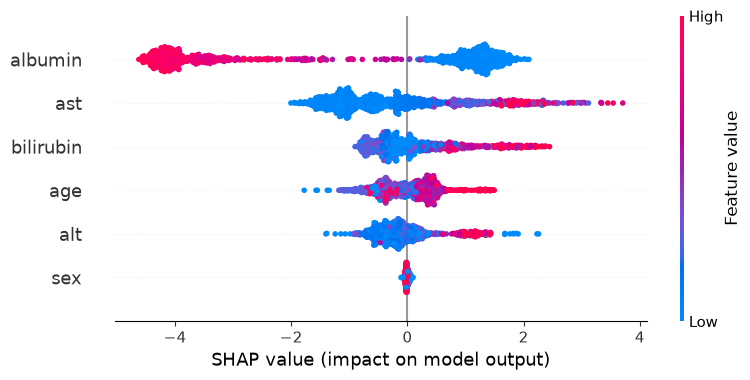

In [8]:
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X)
shap.summary_plot(sv, X, feature_names=FEATURE_ORDER)
# CHECK: high AST / low albumin should push risk UP.
# If sex/age dominates unexpectedly, features are wrong - fix before exporting.

## Cell 7 — export in the ml_infer-compatible shape

**Before running:** open `ml/src/export.py` and confirm what method `ml_infer.predict_risk`
calls (almost certainly `model.predict_proba(X)[:,1]`) and what filenames `config.py` expects.
XGBClassifier already has `predict_proba`, so if the placeholder mirrored that, this drops in clean.

In [9]:
with open(f"{BASE}/greyzone_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open(f"{BASE}/shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)
with open(f"{BASE}/feature_order.json", "w") as f:
    json.dump(FEATURE_ORDER, f)

print("saved:", os.listdir(BASE))

saved: ['feature_order.json', 'greyzone_model.pkl', 'shap_explainer.pkl']


## Cell 8 — drop-in self-test (real org data carries extra columns)

In [10]:
with open(f"{BASE}/greyzone_model.pkl", "rb") as f:
    m2 = pickle.load(f)
with open(f"{BASE}/feature_order.json", "r") as f:
    order = json.load(f)

# Simulate real org data carrying extra cols (plt, diabetes, bmi):
sim = X.copy()
sim["plt"] = 200; sim["diabetes"] = 0; sim["bmi"] = 27
probs = m2.predict_proba(sim[order])[:, 1]        # select by feature_order -> extras ignored
print("round-trip OK, sample probs:", np.round(probs[:5], 3))
assert order == FEATURE_ORDER
print("feature_order matches:", order)

round-trip OK, sample probs: [0.635 0.985 0.884 0.723 0.986]
feature_order matches: ['age', 'sex', 'ast', 'alt', 'bilirubin', 'albumin']
